## Project Overview

This project implements a simple vowel recognition system using Python. The goal is to classify vowel sounds from audio recordings by extracting acoustic features and applying a K-Nearest Neighbours (KNN) classifier.

The dataset contains several `.wav` recordings of spoken vowels. Some recordings are used to train the recognition system, while the remaining recordings are used to test its performance.

The project uses two annotation files:

- `data/DBvocals_train_list_times.txt`
- `data/DBvocals_test_list_times.txt`

Each annotation file contains the path to the corresponding audio recording and ten timestamps. These timestamps indicate the start and end times of the five vowels in each recording:

- `a`
- `e`
- `i`
- `o`
- `u`

Using these annotations, the system assigns frame-level labels to the audio data and evaluates how accurately the classifier recognizes each vowel.

In [1]:
import numpy as np
from scipy.io.wavfile import read
import matplotlib.pyplot as plt
import librosa
from sklearn.neighbors import KNeighborsClassifier

In [5]:
def process_data(dataset, nc, plot_data):
    data_mfcc = np.array([])
    data_labels = np.array([])
    for audio in range(len(dataset)):
        vowel_times = dataset[audio][1:]

        original_path = Path(dataset[audio][0])
        audio_path = Path("data") / "DBvocals" / original_path.name

        y, sr = librosa.load(audio_path, sr=44100)
        # Use parameters : n_fft = 0.025 seconds, hop_length = 0.010
        mfcc_win = 0.025
        mfcc_hop = 0.010
        mfcc = librosa.feature.mfcc(y=y,
                                    sr=sr,
                                    hop_length = 441,
                                    n_fft = 1103,
                                    n_mfcc=nc)

        labels = np.zeros(np.shape(mfcc))[1]
        tt_mfcc  = mfcc_win/2 + mfcc_hop*np.arange(np.shape(mfcc)[1]);
        for vowel_ind in np.arange(1,6):
            start_sample = np.argmin(abs(tt_mfcc-float(vowel_times[(vowel_ind-1)*2])))
            end_sample = np.argmin(abs(tt_mfcc-float(vowel_times[(vowel_ind-1)*2 + 1])))
            labels[start_sample:end_sample] = vowel_ind;

        data_mfcc  = np.concatenate((data_mfcc, mfcc), axis = 1) if data_mfcc.size else mfcc

        data_labels = np.append(data_labels, labels)
        if plot_data:
            tt = np.arange(len(y))/sr
            plt.plot(tt,y)
            plt.plot(tt_mfcc, max(abs(y))/max(labels)*labels, 'r');
            plt.show()

    return (data_mfcc, data_labels)

## Dataset Loading

The dataset is divided into two subsets:

- Training set: used to train the vowel classifier.
- Test set: used to evaluate the system on unseen recordings.

The annotation files contain the audio file paths together with the start and end timestamps of the five vowels present in each recording.

In [6]:
from pathlib import Path

# Load training and testing annotation files
train_data = np.loadtxt(
    "data/DBvocals_train_list_times.txt",
    dtype="unicode"
)

test_data = np.loadtxt(
    "data/DBvocals_test_list_times.txt",
    dtype="unicode"
)

print(f"Training recordings: {len(train_data)}")
print(f"Testing recordings: {len(test_data)}")

Training recordings: 7
Testing recordings: 4


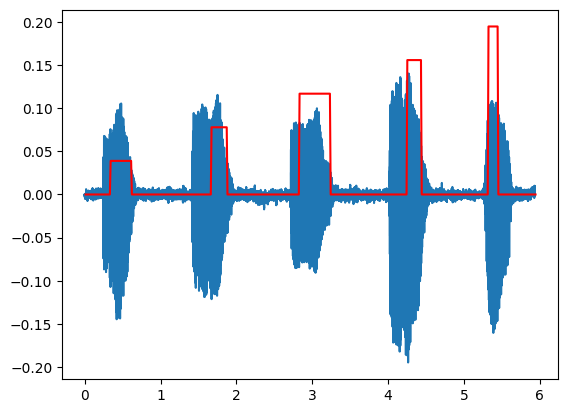

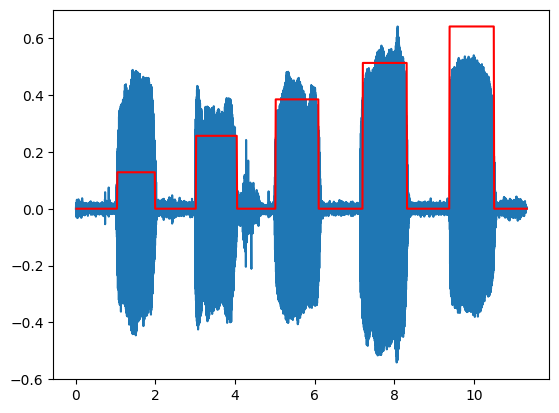

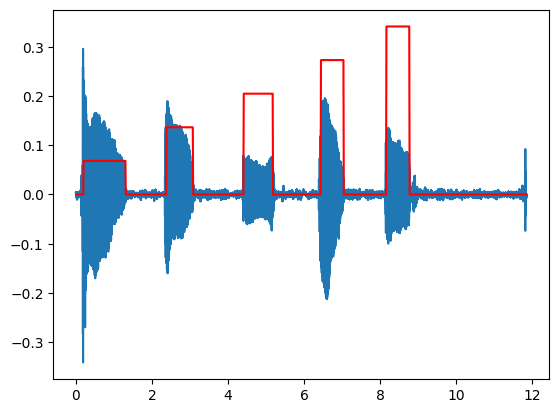

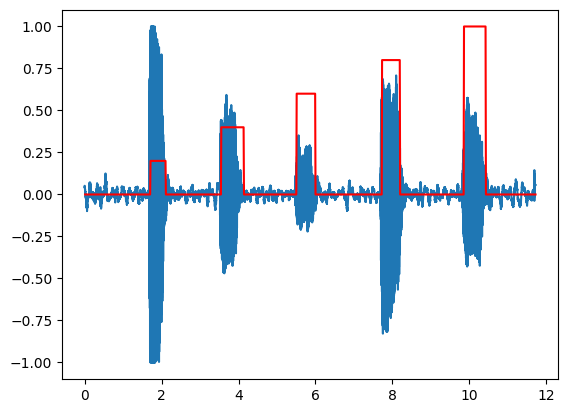

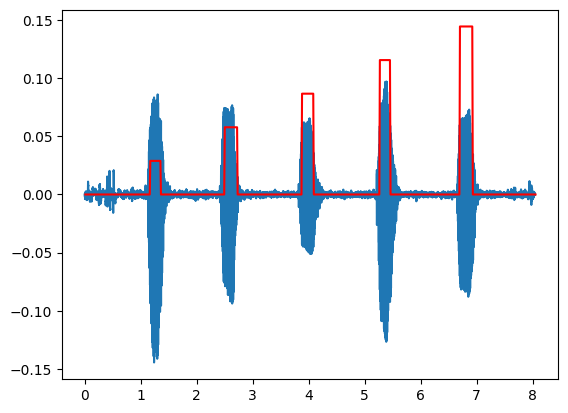

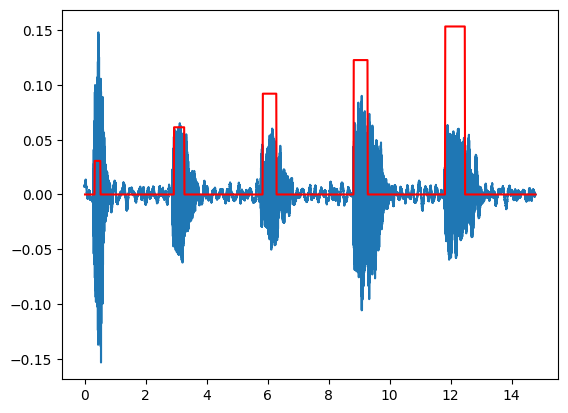

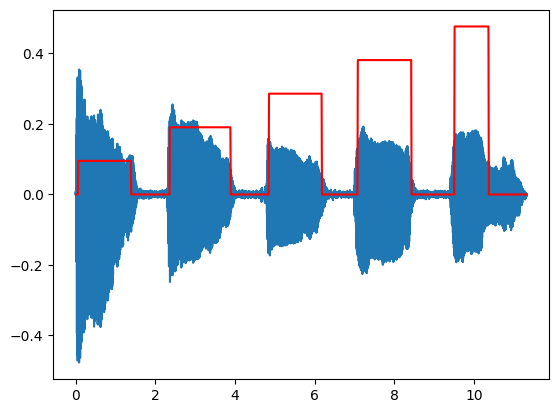

(array([[-6.73341125e+02, -6.59475098e+02, -6.54976562e+02, ...,
         -5.48252625e+02, -5.57145081e+02, -5.60760498e+02],
        [ 1.02383255e+02,  9.30892105e+01,  1.04704742e+02, ...,
          1.31042755e+02,  1.21872665e+02,  1.12570976e+02],
        [ 5.07276840e+01,  4.94717560e+01,  5.43237648e+01, ...,
          1.80709190e+01,  2.02980022e+01,  1.43660135e+01],
        ...,
        [ 9.16675949e+00,  1.27457981e+01,  1.23945217e+01, ...,
          1.73639679e+01,  1.98452454e+01,  8.10830772e-01],
        [ 6.25205421e+00,  7.27523232e+00,  3.77045631e+00, ...,
          5.07422352e+00,  1.62620258e+01, -4.67644691e+00],
        [-1.53249115e-01,  3.05871701e+00,  2.21678829e+00, ...,
         -9.14540100e+00,  1.46911490e+00, -1.05431719e+01]],
       shape=(13, 7499), dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(7499,)))

In [17]:
process_data(train_data, 13, True)

## Frame-Level Label Generation

The annotation files provide the start and end times of each vowel segment in the audio recordings. These timestamps are used to assign a label to each MFCC frame.

The `train_labels` array contains the frame-level class assigned to each training frame:

- `0` = silence or non-vowel segment
- `1` = a
- `2` = e
- `3` = i
- `4` = o
- `5` = u

The following plot shows how the labels are distributed across the training frames.

Shape of train_labels: (7499,)
Unique labels: [0. 1. 2. 3. 4. 5.]


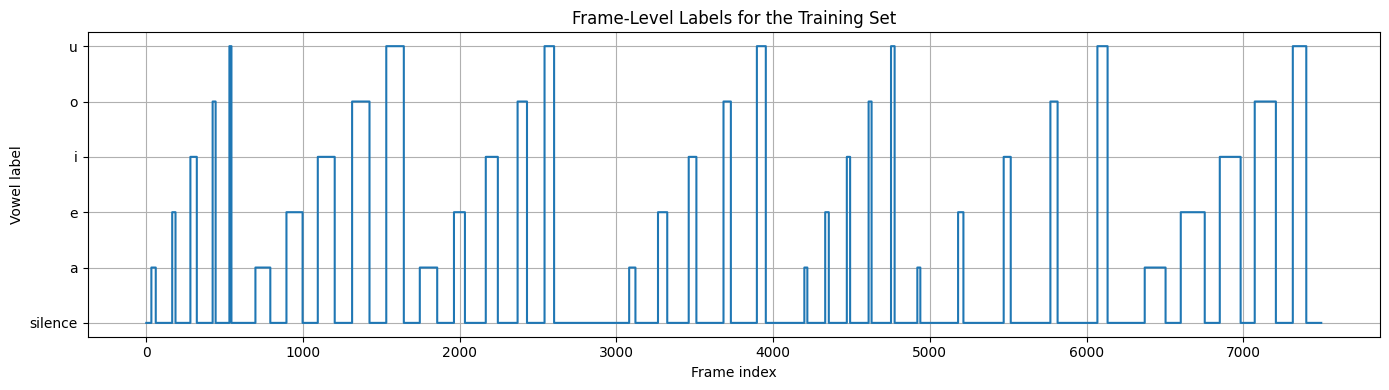

In [8]:
nc = 13   # number of MFCC coefficients

train_mfcc, train_labels = process_data(train_data, nc, plot_data=False)
test_mfcc, test_labels = process_data(test_data, nc, plot_data=False)

print("Shape of train_labels:", train_labels.shape)
print("Unique labels:", np.unique(train_labels))

plt.figure(figsize=(14,4))
plt.step(np.arange(len(train_labels)), train_labels, where='mid')
plt.xlabel("Frame index")
plt.ylabel("Vowel label")
plt.title("Frame-Level Labels for the Training Set")
plt.yticks([0,1,2,3,4,5], ['silence','a','e','i','o','u'])
plt.grid(True)
plt.tight_layout()
plt.show()

## MFCC Feature Representation

After processing the audio recordings, the extracted MFCC coefficients are stored in the `train_mfcc` matrix.

Each column represents a single time frame of the audio signal, while each row corresponds to one MFCC coefficient.

For this experiment, 13 MFCC coefficients are extracted for every frame. The resulting matrix therefore contains:

- Rows: MFCC coefficients
- Columns: audio frames from all training recordings

The following cell displays the dimensions of the feature matrix.

In [9]:
print("Shape of train_mfcc:", np.shape(train_mfcc))

Shape of train_mfcc: (13, 7499)


## Vowel Classification using K-Nearest Neighbours (KNN)

After extracting MFCC features from the audio recordings, a classification stage is required to identify the vowel associated with each frame.

This project uses a K-Nearest Neighbours (KNN) classifier with Euclidean distance as the similarity metric. The classifier compares each test frame with the labelled training frames and assigns the most likely vowel class based on the nearest neighbours.

To improve classification performance, silence frames are excluded from both training and testing data. Only frames corresponding to vowel segments are considered.

The workflow consists of:

1. Selecting only vowel frames from the training set.
2. Building a feature matrix using the MFCC coefficients.
3. Training a KNN classifier with Euclidean distance.
4. Predicting vowel labels for the test frames.
5. Comparing predictions against the reference annotations.

For this implementation, a value of **K = 5** neighbours is used.

In [10]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

def nearest_neighbours(train_labels, train_mfcc, test_labels, test_mfcc, k=5):
    # keep only vowel frames (remove silence = 0)
    idx_train = np.where(train_labels > 0)[0]
    idx_test = np.where(test_labels > 0)[0]

    X_train = train_mfcc[:, idx_train].T
    y_train = train_labels[idx_train]

    X_test = test_mfcc[:, idx_test].T

    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    class_labels = knn.predict(X_test)

    return class_labels, idx_test

In [11]:
class_labels, idx_test = nearest_neighbours(
    train_labels,
    train_mfcc,
    test_labels,
    test_mfcc
)

print("Number of classified vowel frames:", len(class_labels))
print("Predicted classes:", np.unique(class_labels))

Number of classified vowel frames: 1076
Predicted classes: [1. 2. 3. 4. 5.]


## Classification Accuracy Evaluation

To evaluate the performance of the vowel recognition system, the predicted labels are compared against the reference labels provided by the annotations.

The accuracy is computed only on frames corresponding to vowel segments. Silence frames are excluded from the evaluation because they do not belong to any vowel class.

The classification accuracy is defined as the percentage of correctly predicted vowel frames:

\[
Accuracy = \frac{\text{Correct Predictions}}{\text{Total Vowel Frames}} \times 100
\]

A higher accuracy indicates that the extracted MFCC features provide a good representation of the vowel sounds and that the KNN classifier is able to distinguish between different vowel classes effectively.

In [12]:
def compute_accuracy(true_labels, pred_labels):
    return 100 * np.mean(true_labels == pred_labels)

In [13]:
# Classification of the test set
class_labels, idx_test = nearest_neighbours(
    train_labels,
    train_mfcc,
    test_labels,
    test_mfcc
)

# Reference labels corresponding only to vowel frames
true_labels = test_labels[idx_test]

accuracy = compute_accuracy(true_labels, class_labels)

print(f"Classification accuracy: {accuracy:.2f}%")

Classification accuracy: 92.66%


## Experimental Configurations

The vowel recognition system is evaluated under different configurations to study how the amount of training data and the number of MFCC coefficients affect classification performance.

The following experiments are performed:

1. **Training set evaluation** using 13 MFCC coefficients.
2. **Test set evaluation** using 13 MFCC coefficients.
3. **Test set evaluation** using only 3 MFCC coefficients.
4. **Test set evaluation** using only the first 2 training recordings as reference.

These experiments help show how feature dimensionality and training data size influence the accuracy of the KNN classifier.

In [19]:
import numpy as np

# 13 MFCCs
nc = 13

train_mfcc, train_labels = process_data(train_data, nc, False)
test_mfcc, test_labels = process_data(test_data, nc, False)

# Train set evaluation with 13 MFCCs
pred_train, idx_train_eval = nearest_neighbours(
    train_labels,
    train_mfcc,
    train_labels,
    train_mfcc,
    k=5
)

acc_train = compute_accuracy(train_labels[idx_train_eval], pred_train)
print(f"Train accuracy with 13 MFCCs: {acc_train:.2f}%")

# Test set evaluation with 13 MFCCs
pred_test, idx_test_eval = nearest_neighbours(
    train_labels,
    train_mfcc,
    test_labels,
    test_mfcc,
    k=5
)

acc_test = compute_accuracy(test_labels[idx_test_eval], pred_test)
print(f"Test accuracy with 13 MFCCs: {acc_test:.2f}%")

# Test set evaluation with 3 MFCCs
train_mfcc_3, train_labels_3 = process_data(train_data, 3, False)
test_mfcc_3, test_labels_3 = process_data(test_data, 3, False)

pred_test_3, idx_test_eval_3 = nearest_neighbours(
    train_labels_3,
    train_mfcc_3,
    test_labels_3,
    test_mfcc_3,
    k=5
)

acc_test_3 = compute_accuracy(test_labels_3[idx_test_eval_3], pred_test_3)
print(f"Test accuracy with 3 MFCCs: {acc_test_3:.2f}%")

# Test set evaluation using only the first 2 training recordings
train_data_2 = train_data[:2]
train_mfcc_2, train_labels_2 = process_data(train_data_2, 13, False)

pred_test_2, idx_test_eval_2 = nearest_neighbours(
    train_labels_2,
    train_mfcc_2,
    test_labels,
    test_mfcc,
    k=5
)

acc_test_2 = compute_accuracy(test_labels[idx_test_eval_2], pred_test_2)
print(f"Test accuracy using first 2 training files: {acc_test_2:.2f}%")

Train accuracy with 13 MFCCs: 100.00%
Test accuracy with 13 MFCCs: 92.66%
Test accuracy with 3 MFCCs: 55.67%
Test accuracy using first 2 training files: 76.21%


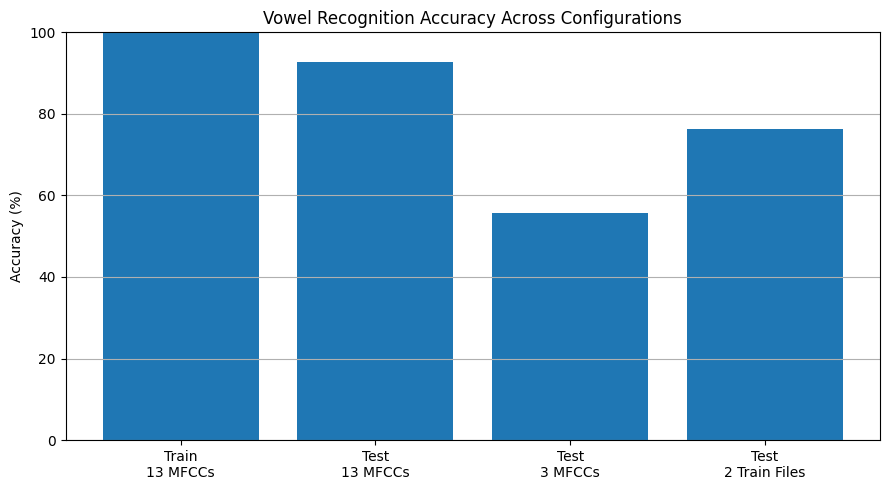

In [15]:
results = {
    "Train\n13 MFCCs": acc_train,
    "Test\n13 MFCCs": acc_test,
    "Test\n3 MFCCs": acc_test_3,
    "Test\n2 Train Files": acc_test_2
}

plt.figure(figsize=(9, 5))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy (%)")
plt.title("Vowel Recognition Accuracy Across Configurations")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Results Discussion

The vowel recognition system achieved excellent performance when using 13 MFCC coefficients, reaching 100.00% accuracy on the training set and 92.66% accuracy on the independent test set. This result indicates that MFCCs provide an effective representation of the spectral characteristics of vowel sounds and that the KNN classifier is able to generalize well to unseen recordings.

When the number of MFCC coefficients was reduced from 13 to 3, the test accuracy dropped significantly to 55.67%. This demonstrates that a larger number of coefficients captures more relevant acoustic information, leading to better discrimination between vowel classes.

A further experiment was conducted using only the first two training recordings as reference data. In this case, the test accuracy decreased to 76.21%, highlighting the importance of having a sufficiently large and diverse training set. With fewer training examples, the classifier has less information available to model the variability of the vowel sounds, which negatively affects performance.

Overall, the experiments show that both feature dimensionality and training data size have a substantial impact on vowel recognition accuracy. The best performance was obtained using the complete training set and 13 MFCC coefficients.